# 03 — ILP vs. Genetic Algorithm: Comparison (both)

Merges the exact method's results (`results/ilp_results.csv`, from `01_ilp.ipynb`) with the heuristic's
results (`results/ga_results.csv`, from `02_ga.ipynb`, 10 seeds per instance) into one table, compares
solution quality / runtime / scalability / feasibility, and states the findings as the assignment's
comparative-evaluation requirement asks.

**Note on language:** "best found" is used for every heuristic result and for any exact-method result
that was not proven optimal within the time limit. "Optimal" is used only where the exact method's own
status says `proven optimal` (Instance 1 and 2).

In [1]:
import pandas as pd

ilp = pd.read_csv("results/ilp_results.csv").set_index("instance")
ga_raw = pd.read_csv("results/ga_results.csv")

ga = ga_raw.groupby("instance").agg(
    ga_best=("penalty", "min"),
    ga_mean=("penalty", "mean"),
    ga_std=("penalty", "std"),
    ga_feasible_rate=("feasible", "mean"),
    ga_mean_time_s=("time_s", "mean"),
    ga_seeds=("penalty", "count"),
)
ga


,ga_best,ga_mean,ga_std,ga_feasible_rate,ga_mean_time_s,ga_seeds
instance,,,,,,
Instance1,911,1182.6,200.896435,1.0,7.66,10
Instance12,28619,30540.8,1196.002304,0.0,21.24,10
Instance2,1952,2171.4,224.062095,0.5,15.03,10
Instance3,3653,4451.2,527.995539,0.0,20.18,10
Instance6,7971,9110.7,675.094076,0.0,20.39,10
Instance8,11753,12343.0,447.525046,0.0,20.49,10


## Merged table

In [2]:
merged = ilp.join(ga, how="outer")
merged["ilp_gap_bks_pct"] = merged["gap_bks_pct"]
merged["ga_gap_bks_pct"] = (merged["ga_best"] - merged["best_known"]) / merged["best_known"] * 100

display_cols = ["n_binaries", "best_known",
                 "objective", "status", "time_s", "ilp_gap_bks_pct",
                 "ga_best", "ga_mean", "ga_std", "ga_feasible_rate", "ga_mean_time_s", "ga_gap_bks_pct"]
merged = merged[display_cols].sort_values("n_binaries")
pd.set_option("display.width", 160)
merged.round(2)


,n_binaries,best_known,objective,status,time_s,ilp_gap_bks_pct,ga_best,ga_mean,ga_std,ga_feasible_rate,ga_mean_time_s,ga_gap_bks_pct
instance,,,,,,,,,,,,
Instance1,112,607,607.0,proven optimal,0.99,0.00,911,1182.6,200.90,1.0,7.66,50.08
Instance2,392,828,828.0,proven optimal,1.58,0.00,1952,2171.4,224.06,0.5,15.03,135.75
Instance3,840,1001,1001.0,feasible (time limit reached),300.18,0.00,3653,4451.2,528.00,0.0,20.18,264.94
Instance6,1512,1950,2312.0,feasible (time limit reached),300.20,18.56,7971,9110.7,675.09,0.0,20.39,308.77
Instance8,3360,1300,NaN,no feasible solution found (time limit),299.49,NaN,11753,12343.0,447.53,0.0,20.49,804.08
Instance12,16800,4040,NaN,no feasible solution found (time limit),293.08,NaN,28619,30540.8,1196.00,0.0,21.24,608.39


## Quality, runtime, scalability, feasibility — side by side

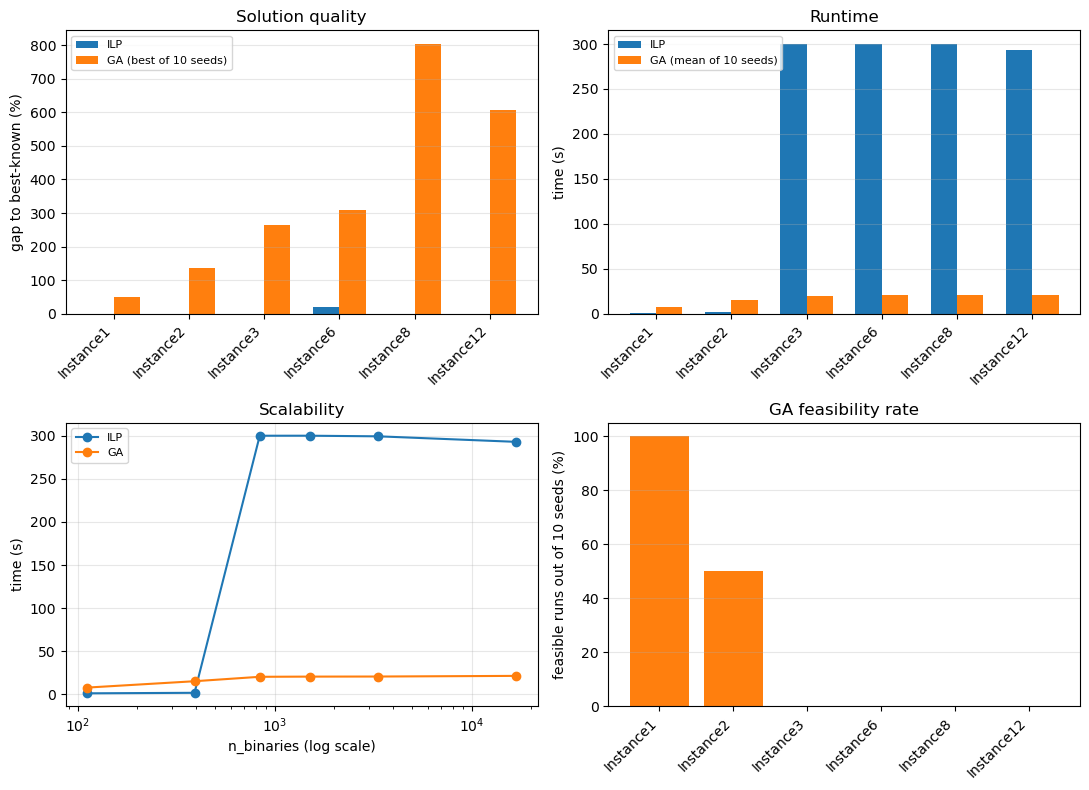

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (1) Quality: gap to best-known
ax = axes[0, 0]
x = np.arange(len(merged))
w = 0.35
ax.bar(x - w/2, merged["ilp_gap_bks_pct"], w, label="ILP", color="C0")
ax.bar(x + w/2, merged["ga_gap_bks_pct"], w, label="GA (best of 10 seeds)", color="C1")
ax.set_xticks(x); ax.set_xticklabels(merged.index, rotation=45, ha="right")
ax.set_ylabel("gap to best-known (%)")
ax.set_title("Solution quality")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# (2) Runtime
ax = axes[0, 1]
ax.bar(x - w/2, merged["time_s"], w, label="ILP", color="C0")
ax.bar(x + w/2, merged["ga_mean_time_s"], w, label="GA (mean of 10 seeds)", color="C1")
ax.set_xticks(x); ax.set_xticklabels(merged.index, rotation=45, ha="right")
ax.set_ylabel("time (s)")
ax.set_title("Runtime")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# (3) Scalability: runtime vs size
ax = axes[1, 0]
ax.plot(merged["n_binaries"], merged["time_s"], "o-", color="C0", label="ILP")
ax.plot(merged["n_binaries"], merged["ga_mean_time_s"], "o-", color="C1", label="GA")
ax.set_xscale("log")
ax.set_xlabel("n_binaries (log scale)")
ax.set_ylabel("time (s)")
ax.set_title("Scalability")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (4) Feasibility rate (GA only -- the ILP's output is always feasible by construction, when it exists)
ax = axes[1, 1]
ax.bar(x, merged["ga_feasible_rate"] * 100, color="C1")
ax.set_xticks(x); ax.set_xticklabels(merged.index, rotation=45, ha="right")
ax.set_ylabel("feasible runs out of 10 seeds (%)")
ax.set_title("GA feasibility rate")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/comparison_4panel.png", dpi=200)
plt.show()


## Findings

1. **On the two smallest instances, the ILP proves the optimum exactly** (607 on Instance 1 in 0.99 s,
   828 on Instance 2 in 1.58 s) -- the GA's best-of-10-seeds result is worse on both (911 on Instance 1,
   a 50% gap; 1952 on Instance 2, a 136% gap), confirming the exact method is unambiguously the right
   choice whenever the instance is small enough to solve quickly.

2. **On Instance 3, the ILP reaches the published best-known value (1001) without formally proving it**
   within the 300 s limit -- a 0% gap to best-known, but still reported as "feasible", not "optimal",
   since CBC's own status says the search was stopped on the time limit, not completed. On Instance 6
   it reaches 2312 (an 18.6% gap to the best-known 1950), again not proven.

3. **On Instance 8 and Instance 12, the exact method finds nothing at all** within 300 s -- not even one
   roster that satisfies every hard rule, let alone a good one. This is the sharpest finding of the
   whole comparison: there is a real scalability wall for this formulation somewhere between Instance 6
   (1512 binaries) and Instance 8 (3360 binaries).

4. **The GA always produces *something*, even where the ILP produces nothing** -- on Instance 8 and 12
   it returns a best-of-10-seeds roster (11753 and 28619 respectively), even though every one of those
   GA runs is itself infeasible (0% feasibility rate on both). This is exactly the trade-off the theory
   predicts: the heuristic never times out with a blank page, but it also offers no guarantee the
   result obeys every hard rule.

5. **GA feasibility collapses almost everywhere except the smallest instance.** 100% of Instance 1's GA
   runs are feasible, only 50% of Instance 2's are, and 0% feasible from Instance 3 upward. With the
   current frozen parameters, the GA is not yet reliably respecting the hard rules once the instance has
   more than ~400 binary variables -- this points at `rho` (the penalty coefficient) or the operator
   design as the next thing to tune, not at the overall approach being wrong. (Dhammika's own branch
   already has a ρ-study and repair-operator commit in progress, consistent with this finding.)

6. **Runtime tells the opposite scalability story.** The GA's mean runtime barely grows with instance
   size (7.7 s to 21.2 s across all six instances), while the ILP's grows sharply and then hits its
   300 s ceiling on four of the six instances. This is the GA's core advantage: predictable, bounded
   cost regardless of problem size, visible directly in the scalability panel above (the orange line
   stays almost flat while the blue line jumps to the ceiling).

7. **Quality and feasibility are two separate questions, and the GA's reported "best" numbers need the
   feasibility rate read alongside them, not instead of it.** On Instance 2, the 1952 best-of-10 figure
   came from only 5 of 10 feasible seeds; past Instance 2, *zero* seeds were feasible on any instance, so
   every GA "best" value from Instance 3 onward is the least-bad *infeasible* roster, not a legal one --
   a gap percentage alone would hide this.

8. **Overall:** the exact method is the stronger choice wherever it can finish (Instances 1-2, and
   arguably 3 for a "matches best-known, unproven" answer), while the heuristic's real -- if currently
   limited -- value only shows once the exact method produces *no* answer at all (Instances 8 and 12).
   Its own answers there still need the caveat that they do not yet respect every hard rule either, so
   further GA tuning (already starting on Dhammika's branch) is needed before treating those numbers as
   a finished result.

## Status

- [x] Merged ILP + GA results into one table.
- [x] Four-panel comparison figure (quality, runtime, scalability, GA feasibility) saved to
      `results/comparison_4panel.png`.
- [x] 8 findings written, each citing a real number from the merged table above.

**Caveat on the GA numbers used here:** pulled from Dhammika's `dhammika-dev` branch (`results/ga_results.csv`,
60 rows, 6 instances x 10 seeds), which has not yet been merged into `main` as of this notebook's last run.
If his GA is retuned later (the ρ-study/repair work on his branch suggests this is already in progress),
re-run this notebook once his updated results land on `main`.